# Final Analysis: PR Merge Outcomes on GitHub

This notebook is the final ADES project narrative. It studies whether PR-level features can help explain and predict GitHub pull request merge outcomes while controlling for target leakage and class imbalance.


## Research question and dataset

**Research question:** Can PR-level features help explain and predict PR merge outcomes on GitHub?

The project uses the Zenodo dataset **GitHub Pull Request Analysis: Sentiment Data and Developer Survey Responses**. The main analysis uses `prfeatures_train_data.csv` and `prfeatures_test_data.csv`, with `merged_or_not` as the locked binary target. The comment and survey files are documented but not used as core inputs because the PR-level task is already well-defined and the timing of comment-derived fields creates leakage risk.


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

RANDOM_STATE = 42
TARGET_COLUMN = "merged_or_not"
TARGET_LABELS = {0: "Not merged", 1: "Merged"}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data" / "raw").exists():
            return candidate
    fallback = Path("/Users/mahmoudali/Documents/ADES - first project")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the ADES project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
CHECKPOINT2_DIR = PROJECT_ROOT / "deliverables" / "checkpoint-2"
FINAL_DIR = PROJECT_ROOT / "deliverables" / "final"
FIGURE_DIR = FINAL_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"

exclude_ids = ["id", "project_id", "creator_id", "last_closer_id"]
exclude_post_outcome = ["last_close_time", "lifetime_minutes", "reopen_or_not"]
ambiguous_features = [
    "num_comments", "has_comments", "num_participants", "core_comment",
    "contrib_comment", "inte_comment", "has_exchange", "at_tag",
    "num_code_comments", "num_code_comments_con", "perc_neg_emotion",
    "perc_pos_emotion", "comment_conflict", "contrib_open", "contrib_cons",
    "contrib_extra", "contrib_agree", "contrib_neur", "inte_open",
    "inte_cons", "inte_extra", "inte_agree", "inte_neur",
    "perc_contrib_pos_emo", "perc_contrib_neg_emo", "perc_inte_pos_emo",
    "perc_inte_neg_emo", "social_strength", "same_user", "ci_build_num",
    "ci_failed_perc", "integrator_availability",
]
candidate_safe_features = [
    "first_pr", "prior_review_num", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "contrib_perc_commit", "sloc", "team_size", "language",
    "open_issue_num", "project_age", "open_pr_num", "fork_num",
    "pr_succ_rate", "test_lines_per_kloc", "stars",
    "test_cases_per_kloc", "asserts_per_kloc", "perc_external_contribs",
    "requester_succ_rate", "churn_addition", "churn_deletion",
    "description_length", "test_inclusion", "ci_exists", "test_churn",
    "num_commits", "src_churn", "files_changed", "friday_effect",
]
safe_usecols = [TARGET_COLUMN, *candidate_safe_features]

questionable_timing_features = [
    "open_pr_num", "pr_succ_rate", "requester_succ_rate", "test_churn"
]
strict_safe_features = [
    feature for feature in candidate_safe_features
    if feature not in questionable_timing_features
]
strict_safe_usecols = [TARGET_COLUMN, *strict_safe_features]

binary_features = [
    "first_pr", "core_member", "test_inclusion", "ci_exists", "friday_effect"
]
categorical_features = ["language"]
numeric_features = [
    feature for feature in candidate_safe_features
    if feature not in binary_features and feature not in categorical_features
]

safe_feature_timing_reason = {
    "first_pr": "Contributor history flag available before or at PR submission.",
    "prior_review_num": "Contributor/reviewer history count before the current PR outcome.",
    "core_member": "Author role/affiliation metadata available before review outcome.",
    "prior_interaction": "Historical author-integrator interaction count before the current PR outcome.",
    "followers": "Contributor profile context available at PR submission.",
    "prev_pullreqs": "Contributor historical PR count before the current PR outcome.",
    "account_creation_days": "Contributor account age at PR submission.",
    "contrib_perc_commit": "Contributor historical share of project commits before the current PR outcome.",
    "sloc": "Project size snapshot available independently of the current PR closure.",
    "team_size": "Project/team context available before the current PR outcome.",
    "language": "Project language category available before modeling; treated as nominal.",
    "open_issue_num": "Project issue-count snapshot used as pre-outcome project context.",
    "project_age": "Repository age at PR submission.",
    "open_pr_num": "Project open-PR workload snapshot; used only under the assumption it is measured at or before PR submission.",
    "fork_num": "Repository popularity/context snapshot available before the current PR outcome.",
    "pr_succ_rate": "Historical project PR success rate; used only as past project context, not including the current PR outcome.",
    "test_lines_per_kloc": "Project test-density snapshot available before closure.",
    "stars": "Repository popularity snapshot available before the current PR outcome.",
    "test_cases_per_kloc": "Project test-density snapshot available before closure.",
    "asserts_per_kloc": "Project test/assertion-density snapshot available before closure.",
    "perc_external_contribs": "Historical project contributor-mix rate before the current PR outcome.",
    "requester_succ_rate": "Requester historical merge-success rate; used only as past contributor context.",
    "churn_addition": "Initial PR diff size available after submission and before final closure.",
    "churn_deletion": "Initial PR diff size available after submission and before final closure.",
    "description_length": "PR description length available at submission.",
    "test_inclusion": "Initial PR diff/test-inclusion flag available before final closure.",
    "ci_exists": "Repository CI configuration/availability flag, not a CI outcome.",
    "test_churn": "Initial PR diff test-churn measure available before final closure.",
    "num_commits": "Current PR commit count from the submitted diff snapshot; not a closure outcome.",
    "src_churn": "Initial PR source-churn measure available before final closure.",
    "files_changed": "Initial PR diff size available before final closure.",
    "friday_effect": "Submission calendar flag available immediately at PR creation.",
}


def availability_reason(feature_name: str) -> str:
    return safe_feature_timing_reason.get(
        feature_name,
        "Conservative pre-outcome PR-level feature retained for modeling.",
    )


def target_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    return pd.DataFrame(
        {
            "split": split,
            "target_value": counts.index,
            "label": [TARGET_LABELS[int(value)] for value in counts.index],
            "count": counts.values,
            "percentage": (counts.values / len(df) * 100).round(2),
        }
    )


def stratified_sample(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if n >= len(df):
        return df.copy()
    _, sample = train_test_split(
        df,
        test_size=n,
        stratify=df[TARGET_COLUMN],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)


def feature_type_groups(feature_list: list[str] | None = None) -> tuple[list[str], list[str], list[str]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    selected_binary = [feature for feature in binary_features if feature in selected_features]
    selected_categorical = [feature for feature in categorical_features if feature in selected_features]
    selected_numeric = [
        feature for feature in selected_features
        if feature not in selected_binary and feature not in selected_categorical
    ]
    return selected_numeric, selected_binary, selected_categorical


def make_preprocessor(feature_list: list[str] | None = None) -> ColumnTransformer:
    selected_numeric, selected_binary, selected_categorical = feature_type_groups(feature_list)
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), selected_numeric),
            ("binary", SimpleImputer(strategy="most_frequent"), selected_binary),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), selected_categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_models(y_train: pd.Series, feature_list: list[str] | None = None) -> dict[str, Pipeline]:
    models: dict[str, Pipeline] = {
        "Dummy majority": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic regression balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Decision tree balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=80,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random forest balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", RandomForestClassifier(
                n_estimators=80,
                max_depth=14,
                min_samples_leaf=60,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "Hist gradient boosting weighted": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", HistGradientBoostingClassifier(
                max_iter=140,
                max_leaf_nodes=31,
                learning_rate=0.08,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            )),
        ]),
    }
    try:
        from xgboost import XGBClassifier

        models["XGBoost weighted"] = Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=1.0,
            )),
        ])
    except Exception as exc:
        print(f"XGBoost unavailable, skipping optional baseline ({type(exc).__name__}).")
    return models


def score_merged_probability(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    elif hasattr(pipeline[-1], "decision_function"):
        decision = pipeline.decision_function(X)
        return 1 / (1 + np.exp(-decision))
    return pipeline.predict(X).astype(float)


def predict_with_not_merged_threshold(
    pipeline: Pipeline,
    X: pd.DataFrame,
    threshold: float,
) -> np.ndarray:
    score_not_merged = 1 - score_merged_probability(pipeline, X)
    return np.where(score_not_merged >= threshold, 0, 1)


def score_predictions(
    name: str,
    y: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str = "default_model_threshold",
    threshold_value: float | None = None,
) -> dict[str, object]:
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    try:
        roc_auc = roc_auc_score(y, y_score_merged)
    except ValueError:
        roc_auc = np.nan
    try:
        average_precision_not_merged = average_precision_score(1 - y, 1 - y_score_merged)
    except ValueError:
        average_precision_not_merged = np.nan

    return {
        "model": name,
        "threshold_label": threshold_label,
        "threshold_value": threshold_value,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_not_merged": precision_score(y, y_pred, pos_label=0, zero_division=0),
        "recall_not_merged": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "f1_not_merged": f1_score(y, y_pred, pos_label=0, zero_division=0),
        "precision_merged": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_merged": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_merged": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "roc_auc_merged": roc_auc,
        "average_precision_not_merged": average_precision_not_merged,
        "tn_not_merged": int(cm[0, 0]),
        "fp_not_merged": int(cm[0, 1]),
        "fn_merged": int(cm[1, 0]),
        "tp_merged": int(cm[1, 1]),
        "actual_not_merged": int(cm[0, :].sum()),
        "predicted_not_merged": int(cm[:, 0].sum()),
        "correct_not_merged": int(cm[0, 0]),
        "missed_not_merged": int(cm[0, 1]),
        "false_not_merged": int(cm[1, 0]),
        "correct_merged": int(cm[1, 1]),
    }


def score_pipeline(
    name: str,
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float | None = None,
    threshold_label: str = "default_model_threshold",
) -> dict[str, object]:
    y_score_merged = score_merged_probability(pipeline, X)
    if threshold is None:
        y_pred = pipeline.predict(X)
        threshold_value = None
    else:
        y_pred = predict_with_not_merged_threshold(pipeline, X, threshold)
        threshold_value = float(threshold)
    return score_predictions(
        name,
        y,
        y_pred,
        y_score_merged,
        threshold_label=threshold_label,
        threshold_value=threshold_value,
    )


def fit_pipeline(name: str, pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    fitted_pipeline = clone(pipeline)
    if name in {"XGBoost weighted", "Hist gradient boosting weighted"}:
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        fitted_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight)
    else:
        fitted_pipeline.fit(X_train, y_train)
    return fitted_pipeline


def fit_and_compare(
    train_df: pd.DataFrame,
    model_sample_size: int,
    validation_size: float = 0.25,
    feature_list: list[str] | None = None,
) -> tuple[pd.DataFrame, dict[str, Pipeline], tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    model_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = model_df[selected_features]
    y = model_df[TARGET_COLUMN]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=validation_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    models = build_models(y_train, selected_features)
    fitted: dict[str, Pipeline] = {}
    rows: list[dict[str, object]] = []

    for name, pipeline in models.items():
        fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
        fitted[name] = fitted_pipeline
        rows.append(score_pipeline(name, fitted_pipeline, X_valid, y_valid))

    comparison = pd.DataFrame(rows).sort_values(
        ["f1_not_merged", "balanced_accuracy", "average_precision_not_merged"],
        ascending=False,
    )
    return comparison.reset_index(drop=True), fitted, (X_train, X_valid, y_train, y_valid)


def threshold_tuning_table(pipeline: Pipeline, X_valid: pd.DataFrame, y_valid: pd.Series) -> pd.DataFrame:
    score_not_merged = 1 - score_merged_probability(pipeline, X_valid)
    precision, recall, thresholds = precision_recall_curve(1 - y_valid, score_not_merged)
    table = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision_not_merged": precision[:-1],
            "recall_not_merged": recall[:-1],
        }
    )
    table["f1_not_merged"] = (
        2 * table["precision_not_merged"] * table["recall_not_merged"]
        / (table["precision_not_merged"] + table["recall_not_merged"]).replace(0, np.nan)
    ).fillna(0)
    table = table.sort_values(
        ["f1_not_merged", "recall_not_merged", "precision_not_merged"],
        ascending=[False, False, False],
    )
    return table.reset_index(drop=True)


def repeated_validation_summary(
    train_df: pd.DataFrame,
    model_sample_size: int,
    feature_list: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    cv_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = cv_df[selected_features]
    y = cv_df[TARGET_COLUMN]
    splitter = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=RANDOM_STATE)
    rows: list[dict[str, object]] = []
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        for name, pipeline in build_models(y_train, selected_features).items():
            fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
            row = score_pipeline(name, fitted_pipeline, X_valid, y_valid)
            row["fold"] = fold_number
            rows.append(row)
    fold_scores = pd.DataFrame(rows)
    metric_columns = [
        "accuracy", "balanced_accuracy", "precision_not_merged",
        "recall_not_merged", "f1_not_merged", "roc_auc_merged",
        "average_precision_not_merged",
    ]
    summary = (
        fold_scores.groupby("model")[metric_columns]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = [
        column[0] if column[1] == "" else f"{column[0]}_{column[1]}"
        for column in summary.columns.to_flat_index()
    ]
    summary = summary.sort_values(
        [
            "f1_not_merged_mean",
            "balanced_accuracy_mean",
            "average_precision_not_merged_mean",
        ],
        ascending=False,
    ).reset_index(drop=True)
    summary.insert(1, "cv_folds", 6)
    summary.insert(2, "model_sample_size", len(cv_df))
    return summary, fold_scores


def bootstrap_metric_intervals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str,
    n_resamples: int = 500,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    y_score_array = np.asarray(y_score_merged)
    metric_rows: list[dict[str, float | str]] = []
    samples: dict[str, list[float]] = {
        "precision_not_merged": [],
        "recall_not_merged": [],
        "f1_not_merged": [],
        "balanced_accuracy": [],
        "roc_auc_merged": [],
    }
    for _ in range(n_resamples):
        indices = rng.integers(0, len(y_true_array), len(y_true_array))
        y_boot = y_true_array[indices]
        pred_boot = y_pred_array[indices]
        score_boot = y_score_array[indices]
        samples["precision_not_merged"].append(precision_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["recall_not_merged"].append(recall_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["f1_not_merged"].append(f1_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["balanced_accuracy"].append(balanced_accuracy_score(y_boot, pred_boot))
        if len(np.unique(y_boot)) == 2:
            samples["roc_auc_merged"].append(roc_auc_score(y_boot, score_boot))
    for metric, values in samples.items():
        clean_values = np.asarray([value for value in values if not pd.isna(value)])
        metric_rows.append(
            {
                "threshold_label": threshold_label,
                "metric": metric,
                "estimate": float(np.mean(clean_values)),
                "ci_lower_95": float(np.quantile(clean_values, 0.025)),
                "ci_upper_95": float(np.quantile(clean_values, 0.975)),
                "bootstrap_resamples": n_resamples,
            }
        )
    return pd.DataFrame(metric_rows)


def feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocess"]
    return preprocessor.get_feature_names_out()


def feature_importance_table(pipeline: Pipeline) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    names = feature_names_from_pipeline(pipeline)
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_[0])
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


In [2]:
print(f"Project root: {PROJECT_ROOT}")
print(f"Final outputs: {FINAL_DIR}")
print(f"Figures: {FIGURE_DIR}")


Project root: /Users/mahmoudali/Documents/ADES - first project
Final outputs: /Users/mahmoudali/Documents/ADES - first project/deliverables/final
Figures: /Users/mahmoudali/Documents/ADES - first project/deliverables/final/figures


## Data loading and audit


,check,result
0,train rows,"1,045,883"
1,test rows,"260,195"
2,train columns,72
3,test columns,72
4,same column names,True
5,same column order,True
6,target in train,True
7,target in test,True
8,explicit train nulls,0
9,explicit test nulls,0


,split,target_value,label,count,percentage
0,train,0,Not merged,113345,10.8400
1,train,1,Merged,932538,89.1600
2,test,0,Not merged,28122,10.8100
3,test,1,Merged,232073,89.1900


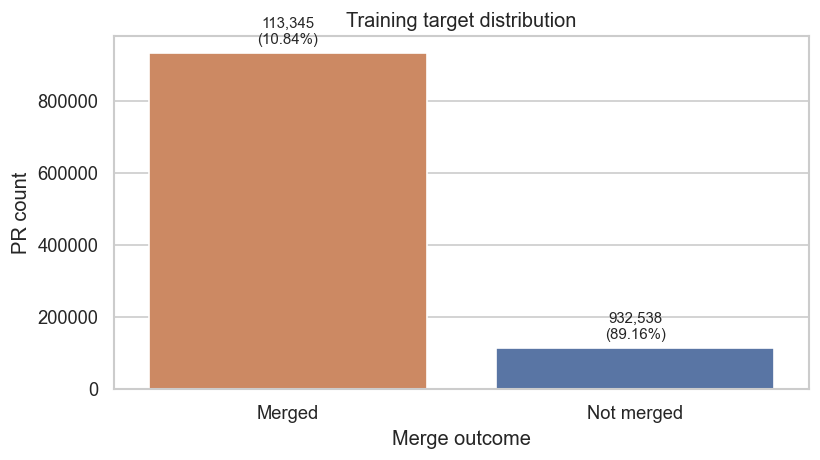

In [3]:
train_full = pd.read_csv(TRAIN_PATH, low_memory=False)
test_full = pd.read_csv(TEST_PATH, low_memory=False)

schema_summary = pd.DataFrame(
    [
        {"check": "train rows", "result": f"{len(train_full):,}"},
        {"check": "test rows", "result": f"{len(test_full):,}"},
        {"check": "train columns", "result": train_full.shape[1]},
        {"check": "test columns", "result": test_full.shape[1]},
        {"check": "same column names", "result": set(train_full.columns) == set(test_full.columns)},
        {"check": "same column order", "result": train_full.columns.equals(test_full.columns)},
        {"check": "target in train", "result": TARGET_COLUMN in train_full.columns},
        {"check": "target in test", "result": TARGET_COLUMN in test_full.columns},
        {"check": "explicit train nulls", "result": int(train_full.isna().sum().sum())},
        {"check": "explicit test nulls", "result": int(test_full.isna().sum().sum())},
        {"check": "duplicate train rows", "result": int(train_full.duplicated().sum())},
        {"check": "duplicate test rows", "result": int(test_full.duplicated().sum())},
    ]
)
target_dist = pd.concat(
    [target_distribution(train_full, "train"), target_distribution(test_full, "test")],
    ignore_index=True,
)
display(schema_summary)
display(target_dist)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_dist[target_dist["split"] == "train"],
    x="label",
    y="count",
    hue="label",
    order=["Merged", "Not merged"],
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=ax,
)
ax.set_title("Training target distribution")
ax.set_xlabel("Merge outcome")
ax.set_ylabel("PR count")
for patch, (_, row) in zip(ax.patches, target_dist[target_dist["split"] == "train"].set_index("label").loc[["Merged", "Not merged"]].reset_index().iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()


## Leakage-aware feature review


In [4]:
feature_review = pd.DataFrame(
    [
        {"feature": TARGET_COLUMN, "status": "target", "reason": "Locked prediction target."},
        *[
            {"feature": feature, "status": "exclude_identifier", "reason": "Entity identifier; not a behavioral predictor."}
            for feature in exclude_ids
        ],
        *[
            {"feature": feature, "status": "exclude_post_outcome", "reason": "Depends on closure or post-decision information."}
            for feature in exclude_post_outcome
        ],
        *[
            {"feature": feature, "status": "hold_back_timing_sensitive", "reason": "Timing relative to merge decision is not yet defensible."}
            for feature in ambiguous_features
        ],
        *[
            {"feature": feature, "status": "candidate_safe", "reason": availability_reason(feature)}
            for feature in candidate_safe_features
        ],
    ]
)
display(
    feature_review.groupby("status", as_index=False)
    .agg(feature_count=("feature", "count"))
    .sort_values("status")
)
display(feature_review)
display(Markdown(f'''
**Strict sensitivity feature set.** The primary model keeps `{len(candidate_safe_features)}` conservative features. A stricter sensitivity model removes `{", ".join(questionable_timing_features)}` because their exact measurement timestamp is easier to challenge. This creates a `{len(strict_safe_features)}`-feature check on whether the main conclusion depends on those timing assumptions.
'''))


,status,feature_count
0,candidate_safe,32
1,exclude_identifier,4
2,exclude_post_outcome,3
3,hold_back_timing_sensitive,32
4,target,1


,feature,status,reason
0,merged_or_not,target,Locked prediction target.
1,id,exclude_identifier,Entity identifier; not a behavioral predictor.
2,project_id,exclude_identifier,Entity identifier; not a behavioral predictor.
3,creator_id,exclude_identifier,Entity identifier; not a behavioral predictor.
4,last_closer_id,exclude_identifier,Entity identifier; not a behavioral predictor.
...,...,...,...
67,test_churn,candidate_safe,Initial PR diff test-churn measure available b...
68,num_commits,candidate_safe,Current PR commit count from the submitted dif...
69,src_churn,candidate_safe,Initial PR source-churn measure available befo...
70,files_changed,candidate_safe,Initial PR diff size available before final cl...



**Strict sensitivity feature set.** The primary model keeps `32` conservative features. A stricter sensitivity model removes `open_pr_num, pr_succ_rate, requester_succ_rate, test_churn` because their exact measurement timestamp is easier to challenge. This creates a `28`-feature check on whether the main conclusion depends on those timing assumptions.


## Exploratory data analysis on conservative features


files_changed        churn_addition         churn_deletion  \
                       mean median           mean  median           mean   
merged_or_not                                                              
Not merged          15.4410 2.0000       618.5550 22.0000       344.6100   
Merged              10.9080 2.0000       412.5720 16.0000       277.5760   

                     description_length         num_commits         
              median               mean  median        mean median  
merged_or_not                                                       
Not merged    5.0000            59.9190 26.0000      4.6960 2.0000  
Merged        5.0000            45.9530 20.0000      3.9840 2.0000

,feature,value,count,merge_rate_pct
0,first_pr,0,1012149,89.4500
1,first_pr,1,33734,80.6800
2,core_member,0,206724,82.5600
3,core_member,1,839159,90.7900
4,test_inclusion,0,825940,89.4300
5,test_inclusion,1,219943,88.1700
6,friday_effect,0,872033,89.1100
7,friday_effect,1,173850,89.4200
8,ci_exists,0,318880,87.0500
9,ci_exists,1,727003,90.0900


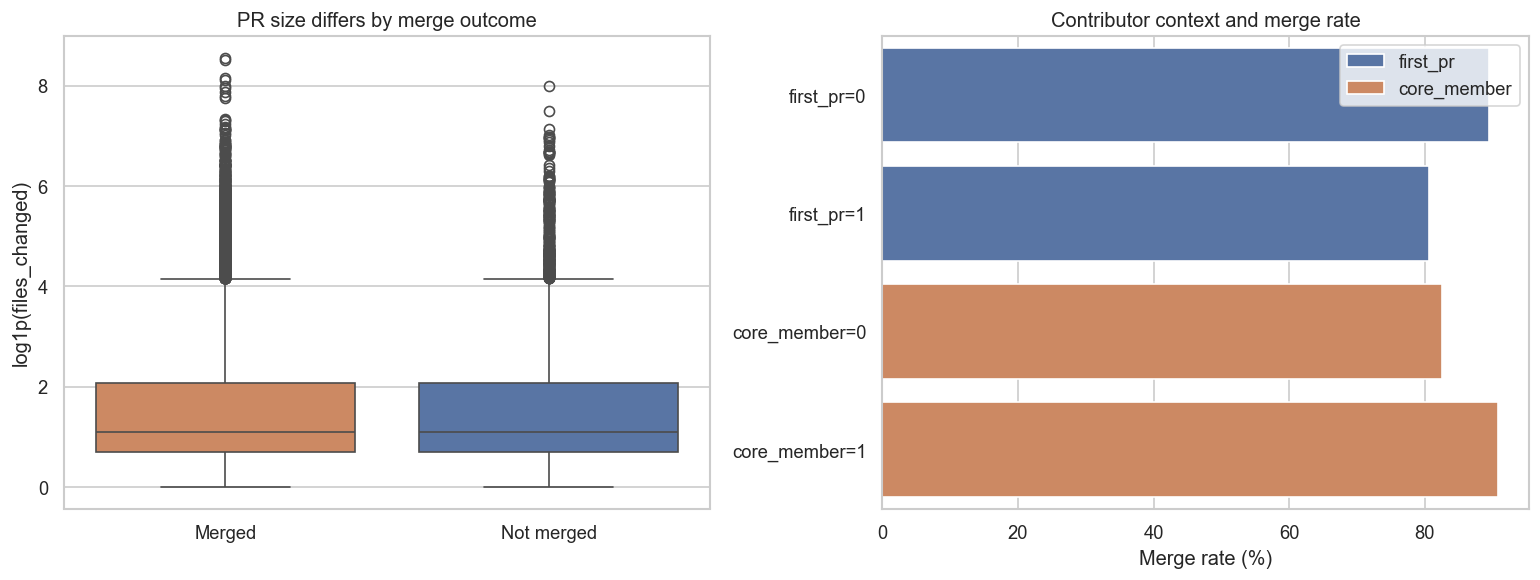

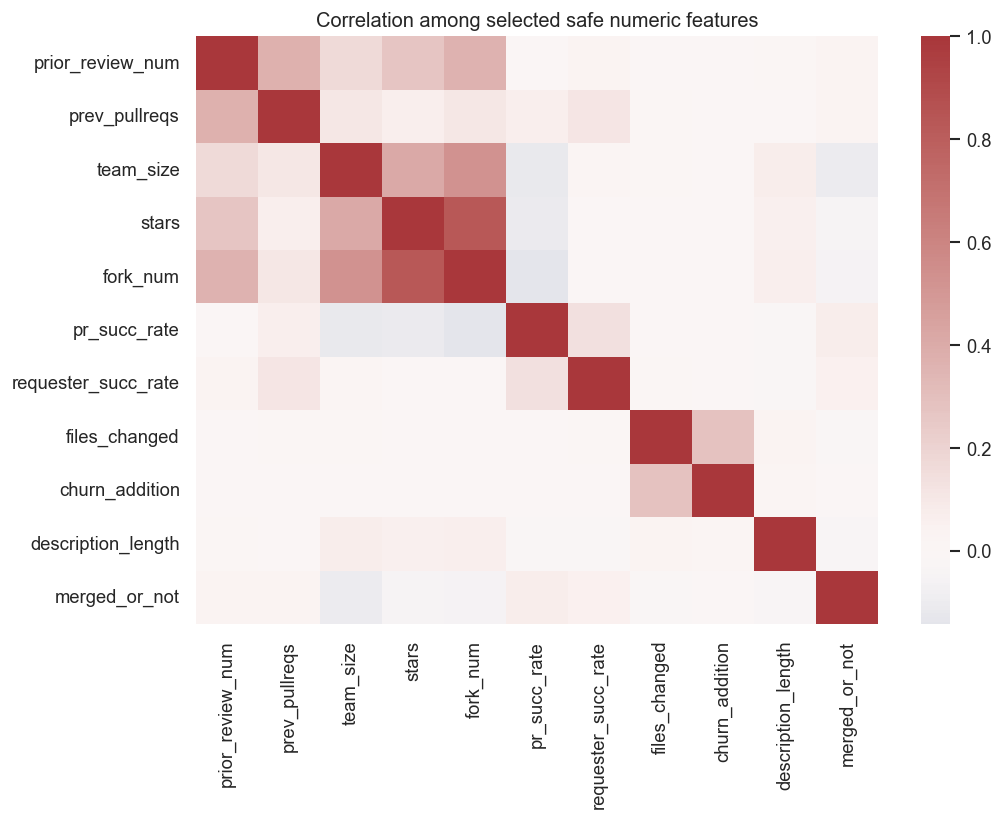


**EDA interpretation.** The class imbalance is large enough that accuracy alone would reward models that mostly predict merges. The exploratory views show usable but moderate signal in PR size, contributor context, project scale, and historical success rates; none of these patterns should be read causally because the dataset is observational.


In [5]:
train_model = train_full[safe_usecols].copy()
test_model = test_full[safe_usecols].copy()

size_features = ["files_changed", "churn_addition", "churn_deletion", "description_length", "num_commits"]
size_summary = (
    train_model.groupby(TARGET_COLUMN)[size_features]
    .agg(["mean", "median"])
    .rename(index=TARGET_LABELS)
    .round(3)
)
display(size_summary)

binary_rate_features = ["first_pr", "core_member", "test_inclusion", "friday_effect", "ci_exists"]
binary_rates = pd.concat(
    [
        train_model.groupby(feature)[TARGET_COLUMN]
        .agg(merge_rate="mean", count="size")
        .reset_index()
        .rename(columns={feature: "value"})
        .assign(feature=feature, merge_rate_pct=lambda df: (df["merge_rate"] * 100).round(2))
        for feature in binary_rate_features
    ],
    ignore_index=True,
)[["feature", "value", "count", "merge_rate_pct"]]
display(binary_rates)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_for_plot = stratified_sample(train_model[[TARGET_COLUMN, *size_features]], 60_000)
sample_for_plot["merge_label"] = sample_for_plot[TARGET_COLUMN].map(TARGET_LABELS)
sns.boxplot(
    data=sample_for_plot.assign(log_files_changed=np.log1p(sample_for_plot["files_changed"])),
    x="merge_label",
    y="log_files_changed",
    hue="merge_label",
    palette=["#DD8452", "#4C72B0"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("PR size differs by merge outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("log1p(files_changed)")

core_plot = binary_rates[binary_rates["feature"].isin(["first_pr", "core_member"])].copy()
core_plot["group"] = core_plot["feature"] + "=" + core_plot["value"].astype(str)
sns.barplot(data=core_plot, x="merge_rate_pct", y="group", hue="feature", dodge=False, ax=axes[1])
axes[1].set_title("Contributor context and merge rate")
axes[1].set_xlabel("Merge rate (%)")
axes[1].set_ylabel("")
axes[1].legend(title="")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_safe_feature_patterns.png", bbox_inches="tight")
plt.show()

corr_features = ["prior_review_num", "prev_pullreqs", "team_size", "stars", "fork_num", "pr_succ_rate", "requester_succ_rate", "files_changed", "churn_addition", "description_length", TARGET_COLUMN]
corr = train_model[corr_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation among selected safe numeric features")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "safe_feature_correlation.png", bbox_inches="tight")
plt.show()

display(Markdown('''
**EDA interpretation.** The class imbalance is large enough that accuracy alone would reward models that mostly predict merges. The exploratory views show usable but moderate signal in PR size, contributor context, project scale, and historical success rates; none of these patterns should be read causally because the dataset is observational.
'''))


## Supervised modeling and validation comparison


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged,actual_not_merged,predicted_not_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,Random forest balanced,default_model_threshold,None,0.8168,0.7041,0.3094,0.5601,0.3986,0.9407,0.8481,0.8920,0.7845,0.4056,3945,3099,8806,49150,7044,12751,3945,3099,8806,49150
1,Hist gradient boosting weighted,default_model_threshold,None,0.7749,0.7109,0.2694,0.6292,0.3773,0.9462,0.7927,0.8626,0.7834,0.4123,4432,2612,12017,45939,7044,16449,4432,2612,12017,45939
2,Decision tree balanced,default_model_threshold,None,0.7418,0.6662,0.2259,0.5697,0.3235,0.9358,0.7627,0.8405,0.7276,0.3409,4013,3031,13752,44204,7044,17765,4013,3031,13752,44204
3,Logistic regression balanced,default_model_threshold,None,0.6379,0.6265,0.1716,0.6119,0.2681,0.9315,0.6411,0.7595,0.6735,0.2185,4310,2734,20802,37154,7044,25112,4310,2734,20802,37154
4,Dummy majority,default_model_threshold,None,0.8916,0.5000,0.0000,0.0000,0.0000,0.8916,1.0000,0.9427,0.5000,0.1084,0,7044,0,57956,7044,0,0,7044,0,57956


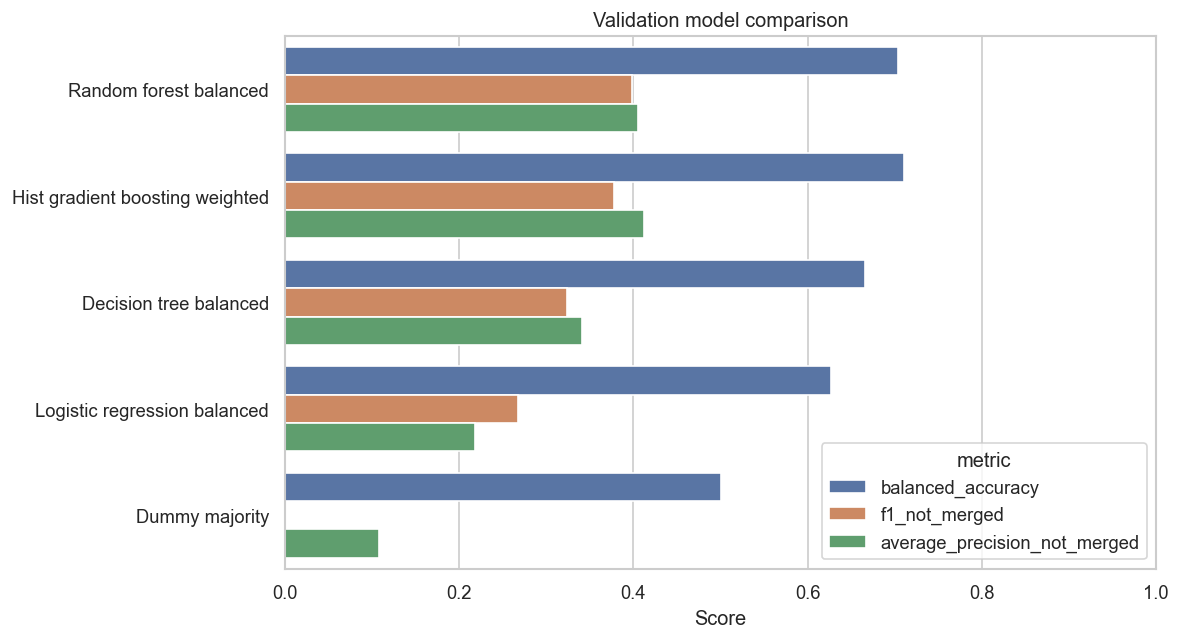

XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,cv_folds,model_sample_size,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_not_merged_mean,precision_not_merged_std,recall_not_merged_mean,recall_not_merged_std,f1_not_merged_mean,f1_not_merged_std,roc_auc_merged_mean,roc_auc_merged_std,average_precision_not_merged_mean,average_precision_not_merged_std
0,Random forest balanced,6,120000,0.8091,0.0026,0.6922,0.0040,0.2939,0.0048,0.5430,0.0072,0.3813,0.0054,0.7659,0.0050,0.3756,0.0051
1,Hist gradient boosting weighted,6,120000,0.7815,0.0025,0.7033,0.0050,0.2715,0.0030,0.6035,0.0121,0.3745,0.0045,0.7693,0.0038,0.3926,0.0046
2,Decision tree balanced,6,120000,0.7205,0.0156,0.6547,0.0072,0.2103,0.0097,0.5707,0.0162,0.3071,0.0096,0.7082,0.0065,0.3102,0.0072
3,Logistic regression balanced,6,120000,0.6392,0.0018,0.6274,0.0046,0.1723,0.0020,0.6122,0.0106,0.2689,0.0034,0.6749,0.0070,0.2173,0.0049
4,Dummy majority,6,120000,0.8916,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.1084,0.0000


,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged,actual_not_merged,predicted_not_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,Random forest balanced,default_model_threshold,NaN,0.8168,0.7041,0.3094,0.5601,0.3986,0.9407,0.8481,0.8920,0.7845,0.4056,3945,3099,8806,49150,7044,12751,3945,3099,8806,49150
1,Random forest balanced,validation_tuned_not_merged_f1,0.5838,0.8740,0.6766,0.4194,0.4246,0.4220,0.9300,0.9286,0.9293,0.7845,0.4056,2991,4053,4140,53816,7044,7131,2991,4053,4140,53816


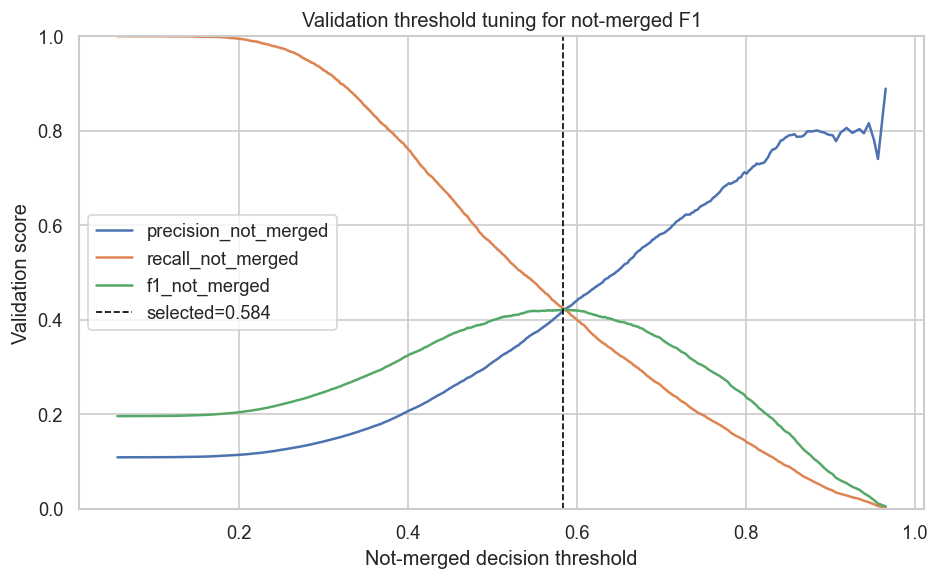


**Model-selection interpretation.** The selected model is **Random forest balanced**, chosen by validation not-merged F1 with balanced accuracy and not-merged average precision as secondary checks. The repeated 3x2 validation table is a stability check: it tests whether the ranking is plausible beyond one lucky internal split, but the final test split remains untouched here.

**Threshold rule.** The tuned not-merged threshold is `0.584` and was selected only from validation predictions. It is carried forward once to the test split, alongside default-threshold metrics, so the tuned result is not hidden inside model selection.


In [6]:
MODEL_SAMPLE_SIZE = 260_000
CV_SAMPLE_SIZE = 120_000
comparison, fitted_models, validation_data = fit_and_compare(train_model, MODEL_SAMPLE_SIZE)
comparison.to_csv(FINAL_DIR / "model_comparison.csv", index=False)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5.5))
metric_plot = comparison.melt(
    id_vars="model",
    value_vars=["balanced_accuracy", "f1_not_merged", "average_precision_not_merged"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=metric_plot, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Validation model comparison")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

selected_model_name = comparison.iloc[0]["model"]
X_train, X_valid, y_train, y_valid = validation_data
selected_validation_model = fitted_models[selected_model_name]

cv_summary, cv_fold_scores = repeated_validation_summary(train_model, CV_SAMPLE_SIZE)
cv_summary.to_csv(FINAL_DIR / "cross_validation_summary.csv", index=False)
cv_fold_scores.to_csv(FINAL_DIR / "cross_validation_fold_scores.csv", index=False)
display(cv_summary)

threshold_table = threshold_tuning_table(selected_validation_model, X_valid, y_valid)
threshold_table.to_csv(FINAL_DIR / "threshold_tuning.csv", index=False)
best_threshold = float(threshold_table.iloc[0]["threshold"])
tuned_validation_metrics = pd.DataFrame([
    score_pipeline(selected_model_name, selected_validation_model, X_valid, y_valid),
    score_pipeline(
        selected_model_name,
        selected_validation_model,
        X_valid,
        y_valid,
        threshold=best_threshold,
        threshold_label="validation_tuned_not_merged_f1",
    ),
])
display(tuned_validation_metrics)

threshold_plot = threshold_table.sort_values("threshold")
step = max(1, len(threshold_plot) // 2_000)
threshold_plot = threshold_plot.iloc[::step]
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=threshold_plot.melt(
        id_vars="threshold",
        value_vars=["precision_not_merged", "recall_not_merged", "f1_not_merged"],
        var_name="metric",
        value_name="score",
    ),
    x="threshold",
    y="score",
    hue="metric",
    ax=ax,
)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1, label=f"selected={best_threshold:.3f}")
ax.set_title("Validation threshold tuning for not-merged F1")
ax.set_xlabel("Not-merged decision threshold")
ax.set_ylabel("Validation score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tuning.png", bbox_inches="tight")
plt.show()

display(Markdown(f'''
**Model-selection interpretation.** The selected model is **{selected_model_name}**, chosen by validation not-merged F1 with balanced accuracy and not-merged average precision as secondary checks. The repeated 3x2 validation table is a stability check: it tests whether the ranking is plausible beyond one lucky internal split, but the final test split remains untouched here.

**Threshold rule.** The tuned not-merged threshold is `{best_threshold:.3f}` and was selected only from validation predictions. It is carried forward once to the test split, alongside default-threshold metrics, so the tuned result is not hidden inside model selection.
'''))


## Final evaluation on the untouched test split


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged,actual_not_merged,predicted_not_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,Random forest balanced,default_model_threshold,NaN,0.8111,0.6729,0.2852,0.4967,0.3623,0.9330,0.8492,0.8891,0.7356,0.3581,13968,14154,35007,197066,28122,48975,13968,14154,35007,197066
1,Random forest balanced,validation_tuned_not_merged_f1,0.5838,0.8695,0.6489,0.3898,0.3675,0.3783,0.9239,0.9303,0.9271,0.7356,0.3581,10334,17788,16180,215893,28122,26514,10334,17788,16180,215893


,threshold_label,actual_not_merged_predicted_not_merged,actual_not_merged_predicted_merged,actual_merged_predicted_not_merged,actual_merged_predicted_merged
0,default_model_threshold,13968,14154,35007,197066
1,validation_tuned_not_merged_f1,10334,17788,16180,215893


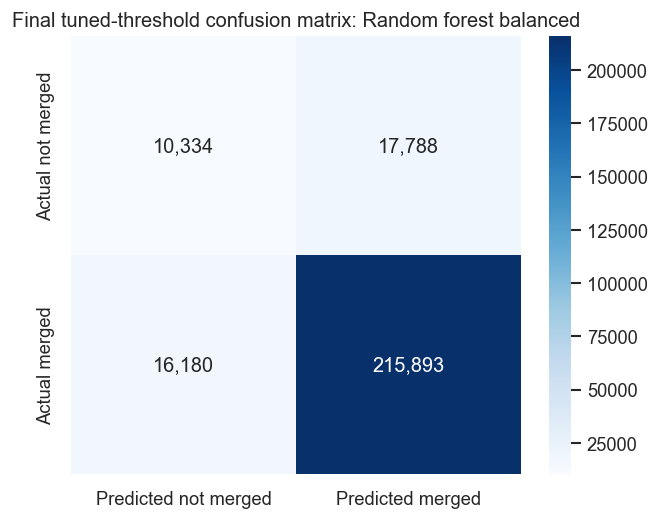

,feature,importance
0,prior_review_num,0.1471
1,contrib_perc_commit,0.1132
2,open_pr_num,0.0524
3,pr_succ_rate,0.0508
4,sloc,0.0458
5,fork_num,0.0454
6,stars,0.0400
7,test_lines_per_kloc,0.0392
8,prior_interaction,0.0389
9,prev_pullreqs,0.0377


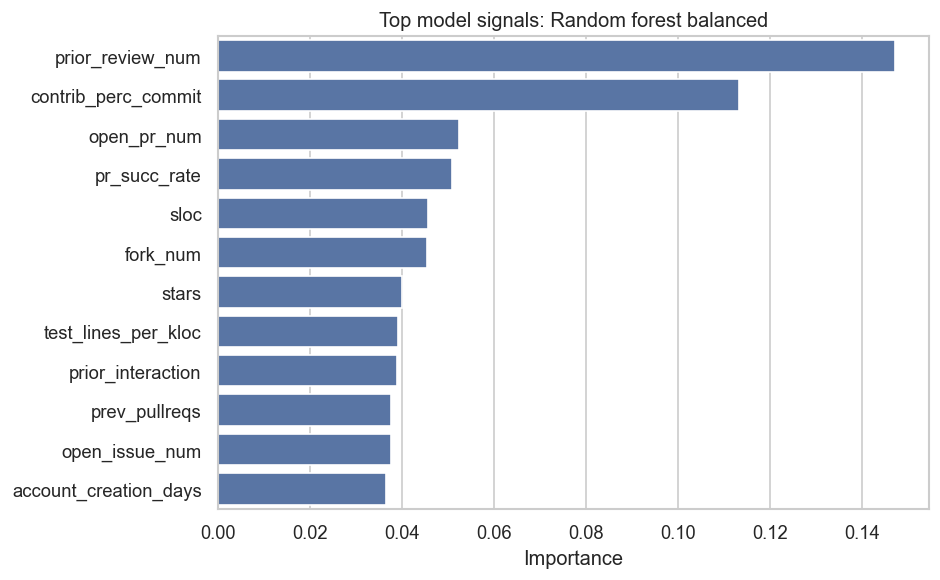

,threshold_label,metric,estimate,ci_lower_95,ci_upper_95,bootstrap_resamples
0,default_model_threshold,precision_not_merged,0.2851,0.2809,0.2892,500
1,default_model_threshold,recall_not_merged,0.4965,0.4906,0.5017,500
2,default_model_threshold,f1_not_merged,0.3622,0.3577,0.3665,500
3,default_model_threshold,balanced_accuracy,0.6728,0.6698,0.6755,500
4,default_model_threshold,roc_auc_merged,0.7354,0.7320,0.7386,500
5,validation_tuned_not_merged_f1,precision_not_merged,0.3896,0.3838,0.3959,500
6,validation_tuned_not_merged_f1,recall_not_merged,0.3673,0.3618,0.3734,500
7,validation_tuned_not_merged_f1,f1_not_merged,0.3781,0.3732,0.3833,500
8,validation_tuned_not_merged_f1,balanced_accuracy,0.6488,0.6460,0.6517,500
9,validation_tuned_not_merged_f1,roc_auc_merged,0.7354,0.7320,0.7386,500


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


,feature_set,evaluation_split,model,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,primary_safe_features,validation,Random forest balanced,0.7041,0.3094,0.5601,0.3986,0.4056
1,strict_features,validation,Random forest balanced,0.6990,0.3030,0.5524,0.3913,0.3957
2,primary_safe_features,test,Random forest balanced,0.6729,0.2852,0.4967,0.3623,0.3581
3,strict_features,test,Random forest balanced,0.6674,0.2765,0.4903,0.3536,0.3539


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


XGBoost unavailable, skipping optional baseline (XGBoostError).


,requested_sample_size,actual_sample_size,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,100000,100000,0.6925,0.3007,0.5367,0.3854,0.3766
1,260000,260000,0.7038,0.3107,0.5582,0.3992,0.4055
2,500000,500000,0.7145,0.3215,0.5770,0.4129,0.4273



**Final-test interpretation.** The default-threshold row is the direct model output. The tuned-threshold row applies a validation-selected rule that deliberately shifts the model toward finding more not-merged PRs. The strict-feature and sample-size tables are sensitivity checks: they test whether the central finding depends on borderline timing assumptions or a single training-sample size.


In [7]:
final_train_df = stratified_sample(train_model[safe_usecols], MODEL_SAMPLE_SIZE)
X_final_train = final_train_df[candidate_safe_features]
y_final_train = final_train_df[TARGET_COLUMN]
X_test = test_model[candidate_safe_features]
y_test = test_model[TARGET_COLUMN]

final_model = fit_pipeline(
    selected_model_name,
    build_models(y_final_train, candidate_safe_features)[selected_model_name],
    X_final_train,
    y_final_train,
)
final_metrics = pd.DataFrame([
    score_pipeline(selected_model_name, final_model, X_test, y_test),
    score_pipeline(
        selected_model_name,
        final_model,
        X_test,
        y_test,
        threshold=best_threshold,
        threshold_label="validation_tuned_not_merged_f1",
    ),
])
final_metrics.to_csv(FINAL_DIR / "final_test_metrics.csv", index=False)
display(final_metrics)

default_pred_test = final_model.predict(X_test)
tuned_pred_test = predict_with_not_merged_threshold(final_model, X_test, best_threshold)
final_score_merged = score_merged_probability(final_model, X_test)
confusion_rows = []
for label, predictions in {
    "default_model_threshold": default_pred_test,
    "validation_tuned_not_merged_f1": tuned_pred_test,
}.items():
    cm = confusion_matrix(y_test, predictions, labels=[0, 1])
    confusion_rows.append({
        "threshold_label": label,
        "actual_not_merged_predicted_not_merged": int(cm[0, 0]),
        "actual_not_merged_predicted_merged": int(cm[0, 1]),
        "actual_merged_predicted_not_merged": int(cm[1, 0]),
        "actual_merged_predicted_merged": int(cm[1, 1]),
    })
final_confusion = pd.DataFrame(confusion_rows)
final_confusion.to_csv(FINAL_DIR / "final_confusion_matrix.csv", index=False)
display(final_confusion)

tuned_cm = confusion_matrix(y_test, tuned_pred_test, labels=[0, 1])
cm_df = pd.DataFrame(
    tuned_cm,
    index=["Actual not merged", "Actual merged"],
    columns=["Predicted not merged", "Predicted merged"],
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title(f"Final tuned-threshold confusion matrix: {selected_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_confusion_matrix.png", bbox_inches="tight")
plt.show()

importances = feature_importance_table(final_model)
importances.to_csv(FINAL_DIR / "feature_importance.csv", index=False)
display(importances.head(15))
if not importances.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=importances.head(12), x="importance", y="feature", ax=ax)
    ax.set_title(f"Top model signals: {selected_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()

ci_default = bootstrap_metric_intervals(
    y_test,
    default_pred_test,
    final_score_merged,
    threshold_label="default_model_threshold",
    n_resamples=500,
)
ci_tuned = bootstrap_metric_intervals(
    y_test,
    tuned_pred_test,
    final_score_merged,
    threshold_label="validation_tuned_not_merged_f1",
    n_resamples=500,
)
final_metric_confidence_intervals = pd.concat([ci_default, ci_tuned], ignore_index=True)
final_metric_confidence_intervals.to_csv(FINAL_DIR / "final_metric_confidence_intervals.csv", index=False)
display(final_metric_confidence_intervals)

strict_comparison, strict_fitted_models, strict_validation_data = fit_and_compare(
    train_model,
    MODEL_SAMPLE_SIZE,
    feature_list=strict_safe_features,
)
X_strict_train, X_strict_valid, y_strict_train, y_strict_valid = strict_validation_data
strict_validation_model_name = (
    selected_model_name if selected_model_name in strict_fitted_models
    else strict_comparison.iloc[0]["model"]
)
strict_validation_metrics = score_pipeline(
    strict_validation_model_name,
    strict_fitted_models[strict_validation_model_name],
    X_strict_valid,
    y_strict_valid,
)

strict_final_df = stratified_sample(train_model[strict_safe_usecols], MODEL_SAMPLE_SIZE)
X_strict_final_train = strict_final_df[strict_safe_features]
y_strict_final_train = strict_final_df[TARGET_COLUMN]
X_strict_test = test_model[strict_safe_features]
strict_final_model = fit_pipeline(
    strict_validation_model_name,
    build_models(y_strict_final_train, strict_safe_features)[strict_validation_model_name],
    X_strict_final_train,
    y_strict_final_train,
)
strict_test_metrics = score_pipeline(
    strict_validation_model_name,
    strict_final_model,
    X_strict_test,
    y_test,
)
primary_validation_metrics = comparison[comparison["model"] == selected_model_name].iloc[0].to_dict()
primary_test_metrics = final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0].to_dict()
leakage_sensitivity = pd.DataFrame([
    {
        "feature_set": "primary_safe_features",
        "evaluation_split": "validation",
        "excluded_timing_sensitive_features": "",
        **primary_validation_metrics,
    },
    {
        "feature_set": "strict_features",
        "evaluation_split": "validation",
        "excluded_timing_sensitive_features": ", ".join(questionable_timing_features),
        **strict_validation_metrics,
    },
    {
        "feature_set": "primary_safe_features",
        "evaluation_split": "test",
        "excluded_timing_sensitive_features": "",
        **primary_test_metrics,
    },
    {
        "feature_set": "strict_features",
        "evaluation_split": "test",
        "excluded_timing_sensitive_features": ", ".join(questionable_timing_features),
        **strict_test_metrics,
    },
])
leakage_sensitivity.to_csv(FINAL_DIR / "leakage_sensitivity.csv", index=False)
display(leakage_sensitivity[[
    "feature_set", "evaluation_split", "model", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged",
]])

sample_size_rows = []
for requested_size in [100_000, 260_000, 500_000]:
    actual_size = min(requested_size, len(train_model))
    sample_df = stratified_sample(train_model[safe_usecols], actual_size, random_state=RANDOM_STATE + requested_size)
    X_sample = sample_df[candidate_safe_features]
    y_sample = sample_df[TARGET_COLUMN]
    X_sample_train, X_sample_valid, y_sample_train, y_sample_valid = train_test_split(
        X_sample,
        y_sample,
        test_size=0.25,
        stratify=y_sample,
        random_state=RANDOM_STATE,
    )
    sample_model = fit_pipeline(
        selected_model_name,
        build_models(y_sample_train, candidate_safe_features)[selected_model_name],
        X_sample_train,
        y_sample_train,
    )
    row = score_pipeline(selected_model_name, sample_model, X_sample_valid, y_sample_valid)
    row["requested_sample_size"] = requested_size
    row["actual_sample_size"] = actual_size
    sample_size_rows.append(row)
sample_size_sensitivity = pd.DataFrame(sample_size_rows)
sample_size_sensitivity.to_csv(FINAL_DIR / "sample_size_sensitivity.csv", index=False)
display(sample_size_sensitivity[[
    "requested_sample_size", "actual_sample_size", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged",
]])

display(Markdown('''
**Final-test interpretation.** The default-threshold row is the direct model output. The tuned-threshold row applies a validation-selected rule that deliberately shifts the model toward finding more not-merged PRs. The strict-feature and sample-size tables are sensitivity checks: they test whether the central finding depends on borderline timing assumptions or a single training-sample size.
'''))


## Unsupervised analysis: clustering PR profiles


,k,silhouette,inertia
0,2,0.4814,"1,772,805.2059"
1,3,0.1909,"1,656,190.0299"
2,4,0.1181,"1,529,961.2939"
3,5,0.1132,"1,469,356.2628"
4,6,0.1371,"1,389,420.0949"


,cluster,pr_count,merge_rate,not_merged_rate,median_files_changed,median_churn_addition,median_description_length,median_num_commits,median_team_size,median_stars,median_requester_succ_rate,cluster_label,interpretation
0,0,66400,89.5600,10.4400,3.0000,17.0000,20.0000,2.0000,6.0000,118.0000,1.0000,lower not-merged / larger-change / smaller-pro...,Cluster 0 groups lower not-merged / larger-cha...
1,1,3600,81.8300,18.1700,2.0000,11.0000,36.0000,2.0000,35.0000,"17,139.5000",0.9857,higher not-merged / smaller-change / larger-pr...,Cluster 1 groups higher not-merged / smaller-c...


,cluster,cluster_label,pr_count,merge_rate,not_merged_rate,interpretation,pc1_explained_variance,pc2_explained_variance,two_component_explained_variance
0,0,lower not-merged / larger-change / smaller-pro...,66400,89.5600,10.4400,Cluster 0 groups lower not-merged / larger-cha...,0.1344,0.1218,0.2562
1,1,higher not-merged / smaller-change / larger-pr...,3600,81.8300,18.1700,Cluster 1 groups higher not-merged / smaller-c...,0.1344,0.1218,0.2562


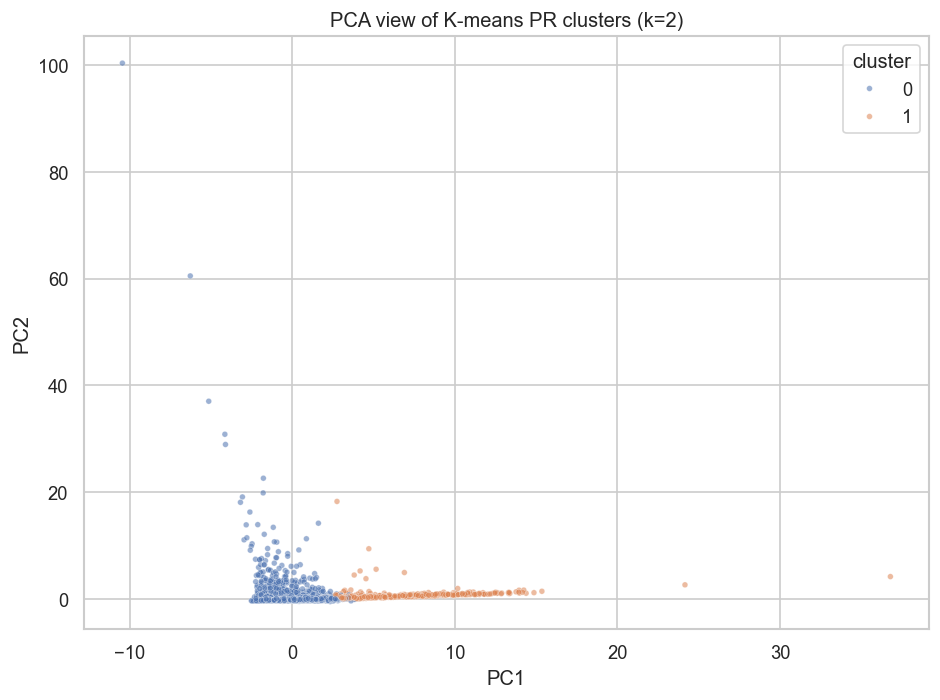


**Cluster interpretation.** The PCA figure is only a two-dimensional projection; PC1 and PC2 explain `0.256` of the transformed feature variance. The clustering is therefore used as a profile summary, not as proof of naturally separated PR types. The labels make the profile differences explicit and keep the unsupervised section tied to the research question.


In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CLUSTER_SAMPLE_SIZE = 70_000
cluster_df = stratified_sample(train_model[safe_usecols], CLUSTER_SAMPLE_SIZE)
X_cluster_raw = cluster_df[candidate_safe_features]
cluster_preprocessor = make_preprocessor()
X_cluster = cluster_preprocessor.fit_transform(X_cluster_raw)

silhouette_rows = []
silhouette_eval_size = min(12_000, X_cluster.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
eval_indices = rng.choice(X_cluster.shape[0], size=silhouette_eval_size, replace=False)
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(X_cluster[eval_indices], labels[eval_indices])
    silhouette_rows.append({"k": k, "silhouette": score, "inertia": model.inertia_})

k_selection = pd.DataFrame(silhouette_rows)
k_selection.to_csv(FINAL_DIR / "cluster_k_selection.csv", index=False)
display(k_selection)

selected_k = int(k_selection.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
kmeans = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

profile_features = ["files_changed", "churn_addition", "description_length", "num_commits", "team_size", "stars", "requester_succ_rate"]
cluster_profile = (
    cluster_df.groupby("cluster")
    .agg(
        pr_count=(TARGET_COLUMN, "size"),
        merge_rate=(TARGET_COLUMN, "mean"),
        not_merged_rate=(TARGET_COLUMN, lambda values: 1 - values.mean()),
        **{f"median_{feature}": (feature, "median") for feature in profile_features},
    )
    .reset_index()
)
cluster_profile["merge_rate"] = (cluster_profile["merge_rate"] * 100).round(2)
cluster_profile["not_merged_rate"] = (cluster_profile["not_merged_rate"] * 100).round(2)
size_median = cluster_profile["median_files_changed"].median()
team_median = cluster_profile["median_team_size"].median()
not_merged_median = cluster_profile["not_merged_rate"].median()
def label_cluster(row: pd.Series) -> str:
    risk = "higher not-merged" if row["not_merged_rate"] >= not_merged_median else "lower not-merged"
    size = "larger-change" if row["median_files_changed"] >= size_median else "smaller-change"
    team = "larger-project" if row["median_team_size"] >= team_median else "smaller-project"
    return f"{risk} / {size} / {team}"
cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile["interpretation"] = cluster_profile.apply(
    lambda row: (
        f"Cluster {int(row['cluster'])} groups {row['cluster_label']} PRs. "
        f"It contains {int(row['pr_count']):,} sampled PRs with a {row['not_merged_rate']:.2f}% not-merged rate."
    ),
    axis=1,
)
cluster_profile.to_csv(FINAL_DIR / "cluster_profile.csv", index=False)
display(cluster_profile)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(X_cluster)
pca_variance = pca.explained_variance_ratio_
cluster_interpretation = cluster_profile[[
    "cluster", "cluster_label", "pr_count", "merge_rate",
    "not_merged_rate", "interpretation",
]].copy()
cluster_interpretation["pc1_explained_variance"] = pca_variance[0]
cluster_interpretation["pc2_explained_variance"] = pca_variance[1]
cluster_interpretation["two_component_explained_variance"] = pca_variance.sum()
cluster_interpretation.to_csv(FINAL_DIR / "cluster_interpretation.csv", index=False)
display(cluster_interpretation)
plot_points = pd.DataFrame(
    {
        "pc1": pca_points[:, 0],
        "pc2": pca_points[:, 1],
        "cluster": cluster_df["cluster"].astype(str),
        "merge_label": cluster_df[TARGET_COLUMN].map(TARGET_LABELS),
    }
)
plot_points = plot_points.sample(n=min(12_000, len(plot_points)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_points, x="pc1", y="pc2", hue="cluster", s=12, alpha=0.55, ax=ax)
ax.set_title(f"PCA view of K-means PR clusters (k={selected_k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_pca.png", bbox_inches="tight")
plt.show()

display(Markdown(f'''
**Cluster interpretation.** The PCA figure is only a two-dimensional projection; PC1 and PC2 explain `{pca_variance.sum():.3f}` of the transformed feature variance. The clustering is therefore used as a profile summary, not as proof of naturally separated PR types. The labels make the profile differences explicit and keep the unsupervised section tied to the research question.
'''))


## Final interpretation


In [9]:
best_validation = comparison.iloc[0]
default_test_row = final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0]
tuned_test_row = final_metrics[final_metrics["threshold_label"] == "validation_tuned_not_merged_f1"].iloc[0]
strict_test_row = leakage_sensitivity[
    (leakage_sensitivity["feature_set"] == "strict_features")
    & (leakage_sensitivity["evaluation_split"] == "test")
].iloc[0]
top_cluster = cluster_profile.sort_values("not_merged_rate", ascending=False).iloc[0]
display(Markdown(f'''
### Answer to the Research Question

**Yes, PR-level features help explain and predict GitHub PR merge outcomes, but the signal is moderate and should be framed as predictive association rather than causality.** The selected model is **{selected_model_name}**, chosen by validation not-merged F1. On the untouched test split:

- Default threshold balanced accuracy: `{default_test_row["balanced_accuracy"]:.3f}`
- Default threshold not-merged F1: `{default_test_row["f1_not_merged"]:.3f}`
- Tuned threshold: `{best_threshold:.3f}` from validation only
- Tuned threshold not-merged precision: `{tuned_test_row["precision_not_merged"]:.3f}`
- Tuned threshold not-merged recall: `{tuned_test_row["recall_not_merged"]:.3f}`
- Tuned threshold not-merged F1: `{tuned_test_row["f1_not_merged"]:.3f}`
- Tuned threshold not-merged average precision: `{tuned_test_row["average_precision_not_merged"]:.3f}`

**Confidence intervals.** The bootstrap intervals in `final_metric_confidence_intervals.csv` quantify sampling uncertainty around the final predictions. They do not remove dataset or feature-timing bias, but they prevent the final notebook from over-reading tiny metric differences.

**Leakage sensitivity.** The strict-feature test removes `{", ".join(questionable_timing_features)}`. Its test not-merged F1 is `{strict_test_row["f1_not_merged"]:.3f}` versus `{default_test_row["f1_not_merged"]:.3f}` for the primary default-threshold model. If the strict result is lower, the conclusion becomes more conservative: safe PR metadata is predictive, but some performance is tied to timing assumptions that should be defended in presentation.

**Unsupervised result.** K-means identified `{selected_k}` PR profile clusters without using the target during fitting. Cluster `{int(top_cluster["cluster"])}` has the highest observed not-merged rate after profiling (`{top_cluster["not_merged_rate"]:.2f}%`) and is labeled `{top_cluster["cluster_label"]}`. This supports interpretation of PR profiles rather than serving as a separate predictor.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, and closure-derived variables were held back unless their availability before the outcome could be defended. The final model also uses a stratified training sample for runtime, so results should be framed as a reproducible course-scale analysis rather than an industrial deployment.
'''))



### Answer to the Research Question

**Yes, PR-level features help explain and predict GitHub PR merge outcomes, but the signal is moderate and should be framed as predictive association rather than causality.** The selected model is **Random forest balanced**, chosen by validation not-merged F1. On the untouched test split:

- Default threshold balanced accuracy: `0.673`
- Default threshold not-merged F1: `0.362`
- Tuned threshold: `0.584` from validation only
- Tuned threshold not-merged precision: `0.390`
- Tuned threshold not-merged recall: `0.367`
- Tuned threshold not-merged F1: `0.378`
- Tuned threshold not-merged average precision: `0.358`

**Confidence intervals.** The bootstrap intervals in `final_metric_confidence_intervals.csv` quantify sampling uncertainty around the final predictions. They do not remove dataset or feature-timing bias, but they prevent the final notebook from over-reading tiny metric differences.

**Leakage sensitivity.** The strict-feature test removes `open_pr_num, pr_succ_rate, requester_succ_rate, test_churn`. Its test not-merged F1 is `0.354` versus `0.362` for the primary default-threshold model. If the strict result is lower, the conclusion becomes more conservative: safe PR metadata is predictive, but some performance is tied to timing assumptions that should be defended in presentation.

**Unsupervised result.** K-means identified `2` PR profile clusters without using the target during fitting. Cluster `1` has the highest observed not-merged rate after profiling (`18.17%`) and is labeled `higher not-merged / smaller-change / larger-project`. This supports interpretation of PR profiles rather than serving as a separate predictor.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, and closure-derived variables were held back unless their availability before the outcome could be defended. The final model also uses a stratified training sample for runtime, so results should be framed as a reproducible course-scale analysis rather than an industrial deployment.
